# Plot the global time series of amoc for a given model and variable

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/g100/home/userexternal/ekoehn00/.conda/envs/eekenv/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Set parameters

In [2]:
lat_choice = 26.5
lat_string = str(lat_choice).replace('.','p')
min_depth_choice = 300
basin_choice = 'atlantic_arctic_ocean'

freq = 'yearly'#'yearly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
#varias = ['msftyz'] # 'tas','tos',
models = ['UKESM1-2','EC-Earth3-ESM-1']#['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM','GISSE2.1-G-CC2']#,
runs = pruns.get_run_list('tipmip_tier1')#[1:]

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()


## Convert time series

In [3]:
def convert_units(varia,da):
    if da.units == 'kg s-1' or da.units == 'kg/s':
        converter = 1/1026 / 10**6
        da_conv = da*converter
        da_conv.attrs["units"] = r'Sv'
    else:    
        da_conv = da
    return da_conv

def get_varia(model):
    if model in ['IPSL-CM6-ESMCO2','GFDL-ESM2M','GISSE2.1-G-CC2','UKESM1-2','EC-Earth3-ESM-1']:
        varia = 'msftyz'
    elif model in ['NorESM2-LM']:
        varia = 'msftmz'
    else:
        raise Exception('Varia not yet chosen for this model.')
    return varia


## Load and plot

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


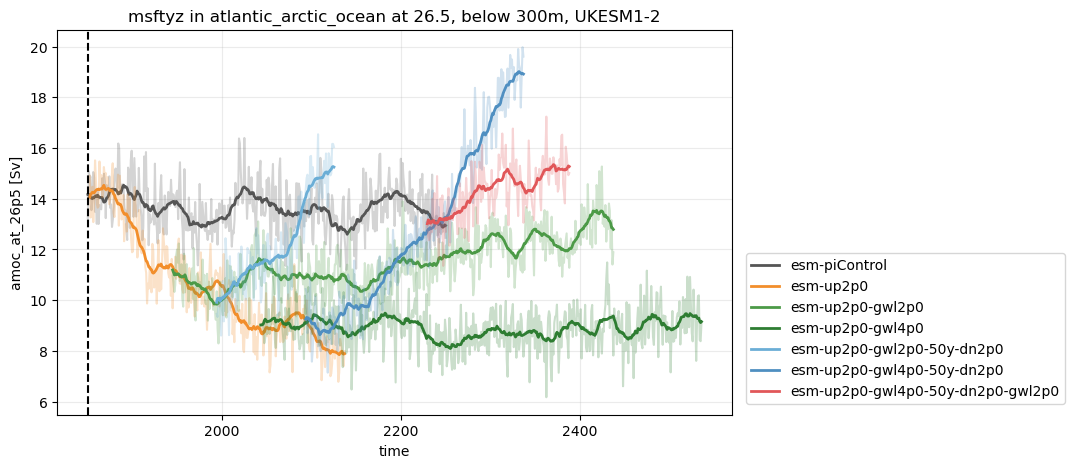

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


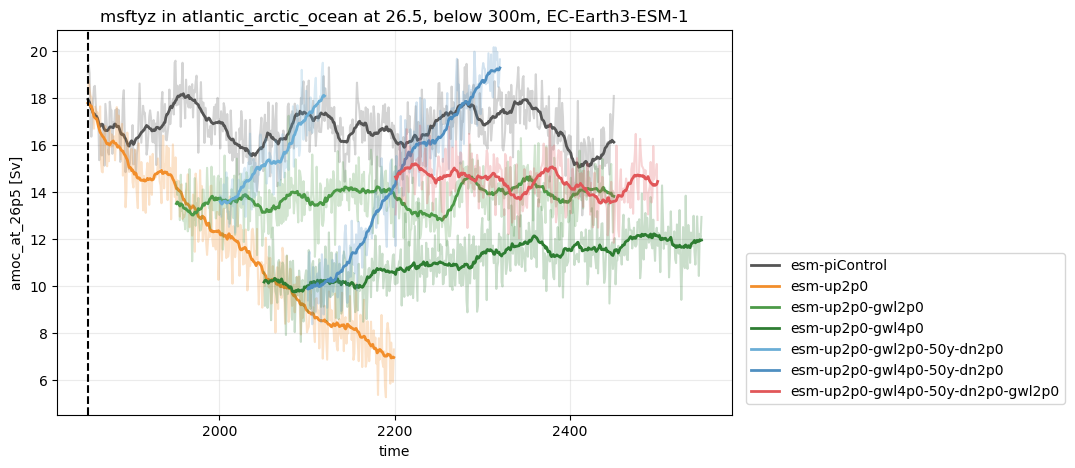

In [4]:
for model in models:
    varia = get_varia(model)
    #stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    global_stats = dict()
    fig, ax = plt.subplots(figsize=(10,5))
    for run in runs:
        try:
            color = run_dict[run].color_id
            load_dir = f'./../01_postprocessed_data/amoc_time_series/{varia}/{model}/{run}/{member}/{freq}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{freq}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"amoc_at_{lat_string}"]
            # convert
            global_stat = convert_units(varia,global_stat)

            # put into dictionary
            global_stats[run] = global_stat
            #for key in global_stats.keys():
            #print(f'... plotting {run} ...')
            global_stats[run].plot(alpha=0.25,color=color) # plot the annual data
            global_stats[run].rolling(time=21, center=True,min_periods=1).mean().plot(alpha=1,linewidth=2,color=color,label=run) # plot the 21year running mean
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq}, amoc.')
    ax.set_title(f"{varia} in {basin_choice} at {lat_choice}, below {min_depth_choice}m, {model}")
    ax.grid(alpha=0.25)
    ax.axvline(cftime.DatetimeGregorian(1850, 1, 1),color='k',linestyle='--')
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()